In [1]:
# ------------------------------------------------------------------------------
# 0. INSTALLATION PACKAGES & LIBRAIRIES ----
# ------------------------------------------------------------------------------
options(timeout = 3600)

system("conda install -c conda-forge libgdal-hdf5")
system("conda install -y r-terra=1.8_42 r-sf=1.0_20 r-gridExtra=2.3 r-ncdf4")

library(terra)
library(sf)
library(gridExtra)
library(dplyr)
library(ggplot2)
library(ncdf4)
library(jsonlite)

# ------------------------------------------------------------------------------
# 1. PARAMÈTRES ET INPUTS ----
# ------------------------------------------------------------------------------

json_path <- "galaxy_inputs/galaxy_inputs.json"
json_data <- fromJSON(json_path)

terra 1.8.42

Linking to GEOS 3.13.0, GDAL 3.10.2, PROJ 9.5.1; sf_use_s2() is TRUE


Attaching package: ‘dplyr’


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:terra’:

    intersect, union


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
file_copernicus <- json_data$Copernicus$path 
subarea <- json_data$subarea       
area_list <- trimws(unlist(strsplit(subarea, ",")))
m <- json_data$multiplier          

# ------------------------------------------------------------------------------
# 2. TÉLÉCHARGEMENT ET CHARGEMENT DES DONNÉES ----
# ------------------------------------------------------------------------------

# Télécharger et charger le fichier NetCDF
nc_file <- nc_open(file_copernicus)
nc_file_raw <- ncvar_get(nc_file,"CHL")
lat_vals <- ncvar_get(nc_file, "latitude")
lon_vals <- ncvar_get(nc_file, "longitude")
nc_close(nc_file)

# Inverser les colonnes (bug connu)
nc_file_raw <- nc_file_raw[, ncol(nc_file_raw):1]

# Créer raster à partir du NetCDF
r <- rast(nrows = length(lat_vals),
          ncols = length(lon_vals),
          xmin = min(lon_vals),
          xmax = max(lon_vals),
          ymin = min(lat_vals),
          ymax = max(lat_vals),
          crs = "EPSG:4326")
values(r) <- as.vector(nc_file_raw)

# Reprojection
raster_project <- project(r, "EPSG:6932")

# Télécharger GEBCO
download.file("https://gis.ccamlr.org/geoserver/www/GEBCO2024_5000.tif", 
              "GEBCO2024_5000.tif", mode = "wb")
gebco_raster <- rast("GEBCO2024_5000.tif")

# ------------------------------------------------------------------------------
# 3. TÉLÉCHARGER ET FILTRER LES SOUS-ZONES ASD ----
# ------------------------------------------------------------------------------

output_dir_asd <- "asd"
dir.create(output_dir_asd, showWarnings = FALSE)

urls_asd <- c(
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.shp",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.shx",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.dbf",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.prj"
)
destfiles_asd <- file.path(output_dir_asd, basename(urls_asd))
for (i in seq_along(urls_asd)) {
  download.file(urls_asd[i], destfiles_asd[i], mode = "wb")
}

# Lire le shapefile et filtrer les sous-zones
ASDs <- st_read(file.path(output_dir_asd, "asd-shapefile-EPSG6932.shp"), quiet = TRUE)
subareas_selected <- ASDs %>% filter(GAR_Short_ %in% area_list)
subareas_vect <- vect(subareas_selected)

# ------------------------------------------------------------------------------
# 4. CALCUL TAILLE DE L'IMAGE EN FONCTION DE LA ZONE ----
# ------------------------------------------------------------------------------

# Juste pour calculer l'étendue de la zone sélectionnée
raster_cropped <- crop(raster_project, subareas_vect)
raster_masked <- mask(raster_cropped, subareas_vect)

raster_extent <- ext(raster_masked)
w <- abs(raster_extent[2] - raster_extent[1]) / 10000
h <- abs(raster_extent[4] - raster_extent[3]) / 10000

# ------------------------------------------------------------------------------
# 5. AFFICHAGE FINAL ET EXPORT PNG ----
# ------------------------------------------------------------------------------

png(filename = "outputs/Fig9.png", width = w * m, height = h * m)

# Palette pour chlorophylle
custom_palette <- colorRampPalette(c("blue", "green", "yellow", "red"))(100)
custom_palette <- c(custom_palette, "red")
breaks <- c(seq(0, 5, length.out = 100), Inf)

# Couleurs pour GEBCO
my_colors <- c("white", "grey")
my_breaks <- c(-Inf, 0, Inf)

# Affichage GEBCO
plot(gebco_raster, col = my_colors, breaks = my_breaks, legend = FALSE, axes = FALSE, box = FALSE,mar=c(0,0,0,0),
     xlim = c(raster_extent[1], raster_extent[2]),
     ylim = c(raster_extent[3], raster_extent[4]),
     main = "Chlorophylle et limites ASD")

# Affichage raster CHL
plot(raster_project, col = custom_palette, breaks = breaks, legend = TRUE, add = TRUE)

# Add ASD boundaries in red
plot(subareas_vect, add = TRUE, lwd = 0.75*m, border = 'black')

zones <- st_read("asd/asd-shapefile-EPSG6932.shp")    
centroids <- st_centroid(st_geometry(zones))
text(st_coordinates(centroids), labels = zones$GAR_Long_L, col = "black", cex = 1*m) 

dev.off()


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Error 1: unhandled axis direction: "North along 90 deg East"”
Warning message:
“[mask] CRS do not match”


Reading layer `asd-shapefile-EPSG6932' from data source 
  `/data/jwd06/pulsar_staging/82563704/working/jupyter/asd/asd-shapefile-EPSG6932.shp' 
  using driver `ESRI Shapefile'


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Error 1: unhandled axis direction: "North along 90 deg East"”


Simple feature collection with 19 features and 16 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -3348556 ymin: -3329339 xmax: 4815055 ymax: 4371127
CRS:           NA


pdf 
  2

Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Error 1: unhandled axis direction: "North along 90 deg East"”
Warning message:
“[mask] CRS do not match”


Reading layer `asd-shapefile-EPSG6932' from data source 
  `/data/jwd06/pulsar_staging/82563704/working/jupyter/asd/asd-shapefile-EPSG6932.shp' 
  using driver `ESRI Shapefile'


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Error 1: unhandled axis direction: "North along 90 deg East"”


Simple feature collection with 19 features and 16 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -3348556 ymin: -3329339 xmax: 4815055 ymax: 4371127
CRS:           NA


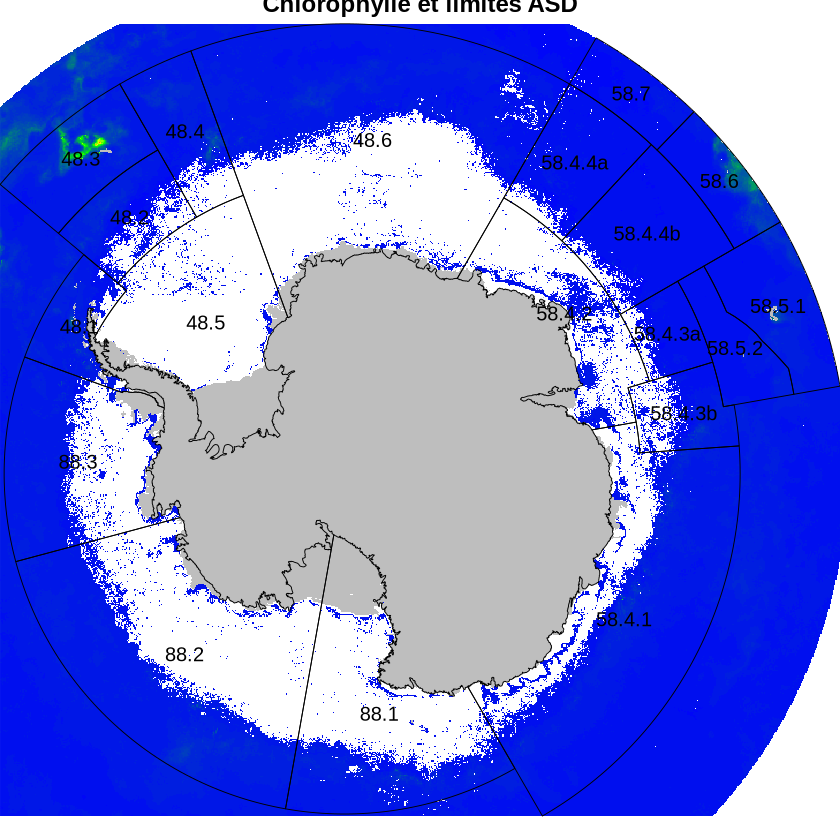

In [33]:
file_copernicus <- json_data$Copernicus$path 
#subarea <- json_data$subarea  
subarea <- "883,882,481,484,482,483,5843a,5843b,5852,485,486,5841,5842,881,5844a,587,586,5851,5844b"    
area_list <- trimws(unlist(strsplit(subarea, ",")))
m <- json_data$multiplier          

# ------------------------------------------------------------------------------
# 2. TÉLÉCHARGEMENT ET CHARGEMENT DES DONNÉES ----
# ------------------------------------------------------------------------------

# Télécharger et charger le fichier NetCDF
nc_file <- nc_open(file_copernicus)
nc_file_raw <- ncvar_get(nc_file,"CHL")
lat_vals <- ncvar_get(nc_file, "latitude")
lon_vals <- ncvar_get(nc_file, "longitude")
nc_close(nc_file)

# Inverser les colonnes (bug connu)
nc_file_raw <- nc_file_raw[, ncol(nc_file_raw):1]

# Créer raster à partir du NetCDF
r <- rast(nrows = length(lat_vals),
          ncols = length(lon_vals),
          xmin = min(lon_vals),
          xmax = max(lon_vals),
          ymin = min(lat_vals),
          ymax = max(lat_vals),
          crs = "EPSG:4326")
values(r) <- as.vector(nc_file_raw)

# Reprojection
raster_project <- project(r, "EPSG:6932")

# Télécharger GEBCO
#download.file("https://gis.ccamlr.org/geoserver/www/GEBCO2024_5000.tif", "GEBCO2024_5000.tif", mode = "wb")
gebco_raster <- rast("GEBCO2024_5000.tif")

# ------------------------------------------------------------------------------
# 3. TÉLÉCHARGER ET FILTRER LES SOUS-ZONES ASD ----
# ------------------------------------------------------------------------------

output_dir_asd <- "asd"
dir.create(output_dir_asd, showWarnings = FALSE)

urls_asd <- c(
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.shp",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.shx",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.dbf",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.prj"
)
#destfiles_asd <- file.path(output_dir_asd, basename(urls_asd))
#for (i in seq_along(urls_asd)) {
  #download.file(urls_asd[i], destfiles_asd[i], mode = "wb")
#}

# Lire le shapefile et filtrer les sous-zones
ASDs <- st_read(file.path(output_dir_asd, "asd-shapefile-EPSG6932.shp"), quiet = TRUE)
subareas_selected <- ASDs %>% filter(GAR_Short_ %in% area_list)
subareas_vect <- vect(subareas_selected)

# ------------------------------------------------------------------------------
# 4. CALCUL TAILLE DE L'IMAGE EN FONCTION DE LA ZONE ----
# ------------------------------------------------------------------------------

# Juste pour calculer l'étendue de la zone sélectionnée
raster_cropped <- crop(raster_project, subareas_vect)
raster_masked <- mask(raster_cropped, subareas_vect)

raster_extent <- ext(raster_masked)
w <- abs(raster_extent[2] - raster_extent[1]) / 10000
h <- abs(raster_extent[4] - raster_extent[3]) / 10000

# ------------------------------------------------------------------------------
# 5. AFFICHAGE FINAL ET EXPORT PNG ----
# ------------------------------------------------------------------------------

#png(filename = "outputs/Fig9.png", width = w * m, height = h * m)

# Palette pour chlorophylle
custom_palette <- colorRampPalette(c("blue", "green", "yellow", "red"))(100)
custom_palette <- c(custom_palette, "red")
breaks <- c(seq(0, 5, length.out = 100), Inf)

# Couleurs pour GEBCO
my_colors <- c("white", "grey")
my_breaks <- c(-Inf, 0, Inf)

# Affichage GEBCO
plot(gebco_raster, col = my_colors, breaks = my_breaks, legend = FALSE, axes = FALSE, box = FALSE,mar=c(0,0,0,0),
     xlim = c(raster_extent[1], raster_extent[2]),
     ylim = c(raster_extent[3], raster_extent[4]),
     main = "Chlorophylle et limites ASD")

# Affichage raster CHL
plot(raster_project, col = custom_palette, breaks = breaks, legend = TRUE, add = TRUE)

# Add ASD boundaries in red
plot(subareas_vect, add = TRUE, lwd = 0.75*m, border = 'black')

zones <- st_read("asd/asd-shapefile-EPSG6932.shp")    
centroids <- st_centroid(st_geometry(zones))
text(st_coordinates(centroids), labels = zones$GAR_Long_L, col = "black", cex = 1*m) 

#dev.off()


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Error 1: unhandled axis direction: "North along 90 deg East"”
Warning message:
“[mask] CRS do not match”


Reading layer `asd-shapefile-EPSG6932' from data source 
  `/data/jwd06/pulsar_staging/82563704/working/jupyter/asd/asd-shapefile-EPSG6932.shp' 
  using driver `ESRI Shapefile'


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Error 1: unhandled axis direction: "North along 90 deg East"”


Simple feature collection with 19 features and 16 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -3348556 ymin: -3329339 xmax: 4815055 ymax: 4371127
CRS:           NA


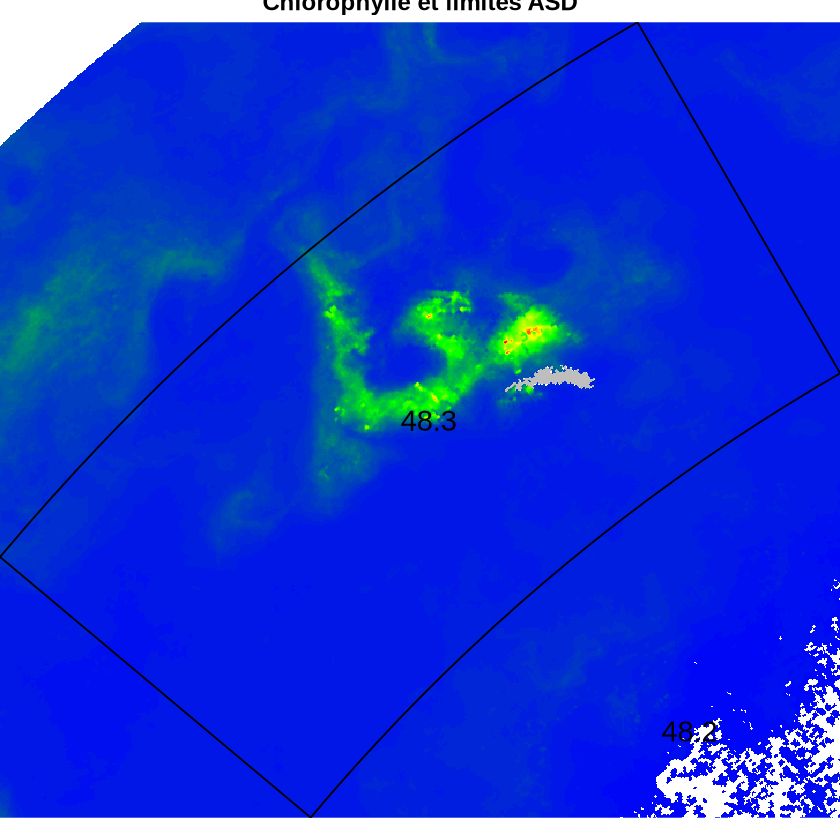

In [31]:
file_copernicus <- json_data$Copernicus$path 
#subarea <- json_data$subarea  
subarea <- "483"    
area_list <- trimws(unlist(strsplit(subarea, ",")))
m <- json_data$multiplier          

# ------------------------------------------------------------------------------
# 2. TÉLÉCHARGEMENT ET CHARGEMENT DES DONNÉES ----
# ------------------------------------------------------------------------------

# Télécharger et charger le fichier NetCDF
nc_file <- nc_open(file_copernicus)
nc_file_raw <- ncvar_get(nc_file,"CHL")
lat_vals <- ncvar_get(nc_file, "latitude")
lon_vals <- ncvar_get(nc_file, "longitude")
nc_close(nc_file)

# Inverser les colonnes (bug connu)
nc_file_raw <- nc_file_raw[, ncol(nc_file_raw):1]

# Créer raster à partir du NetCDF
r <- rast(nrows = length(lat_vals),
          ncols = length(lon_vals),
          xmin = min(lon_vals),
          xmax = max(lon_vals),
          ymin = min(lat_vals),
          ymax = max(lat_vals),
          crs = "EPSG:4326")
values(r) <- as.vector(nc_file_raw)

# Reprojection
raster_project <- project(r, "EPSG:6932")

# Télécharger GEBCO
#download.file("https://gis.ccamlr.org/geoserver/www/GEBCO2024_5000.tif", "GEBCO2024_5000.tif", mode = "wb")
gebco_raster <- rast("GEBCO2024_5000.tif")

# ------------------------------------------------------------------------------
# 3. TÉLÉCHARGER ET FILTRER LES SOUS-ZONES ASD ----
# ------------------------------------------------------------------------------

output_dir_asd <- "asd"
dir.create(output_dir_asd, showWarnings = FALSE)

urls_asd <- c(
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.shp",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.shx",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.dbf",
  "https://raw.githubusercontent.com/ccamlr/data/refs/tags/v0.5.0/geographical_data/asd/asd-shapefile-EPSG6932.prj"
)
#destfiles_asd <- file.path(output_dir_asd, basename(urls_asd))
#for (i in seq_along(urls_asd)) {
  #download.file(urls_asd[i], destfiles_asd[i], mode = "wb")
#}

# Lire le shapefile et filtrer les sous-zones
ASDs <- st_read(file.path(output_dir_asd, "asd-shapefile-EPSG6932.shp"), quiet = TRUE)
subareas_selected <- ASDs %>% filter(GAR_Short_ %in% area_list)
subareas_vect <- vect(subareas_selected)

# ------------------------------------------------------------------------------
# 4. CALCUL TAILLE DE L'IMAGE EN FONCTION DE LA ZONE ----
# ------------------------------------------------------------------------------

# Juste pour calculer l'étendue de la zone sélectionnée
raster_cropped <- crop(raster_project, subareas_vect)
raster_masked <- mask(raster_cropped, subareas_vect)

raster_extent <- ext(raster_masked)
w <- abs(raster_extent[2] - raster_extent[1]) / 10000
h <- abs(raster_extent[4] - raster_extent[3]) / 10000

# ------------------------------------------------------------------------------
# 5. AFFICHAGE FINAL ET EXPORT PNG ----
# ------------------------------------------------------------------------------

#png(filename = "outputs/Fig9.png", width = w * m, height = h * m)

# Palette pour chlorophylle
custom_palette <- colorRampPalette(c("blue", "green", "yellow", "red"))(100)
custom_palette <- c(custom_palette, "red")
breaks <- c(seq(0, 5, length.out = 100), Inf)

# Couleurs pour GEBCO
my_colors <- c("white", "grey")
my_breaks <- c(-Inf, 0, Inf)

# Affichage GEBCO
plot(gebco_raster, col = my_colors, breaks = my_breaks, legend = FALSE, axes = FALSE, box = FALSE,mar=c(0,0,0,0),
     xlim = c(raster_extent[1], raster_extent[2]),
     ylim = c(raster_extent[3], raster_extent[4]),
     main = "Chlorophylle et limites ASD")

# Affichage raster CHL
plot(raster_project, col = custom_palette, breaks = breaks, legend = TRUE, add = TRUE)

# Add ASD boundaries in red
plot(subareas_vect, add = TRUE, lwd = h*m/100, border = 'black')

zones <- st_read("asd/asd-shapefile-EPSG6932.shp")    
centroids <- st_centroid(st_geometry(zones))
text(st_coordinates(centroids), labels = zones$GAR_Long_L, col = "black", cex = h*m/100) 

#dev.off()
